# Flu Shot Learning — Notebook 3: XGBoost + Target Encoding + 5-Fold Stratified CV

**Goal:** Test whether careful manual target encoding can match/beat CatBoost's built-in categorical handling, leveraging XGBoost's distinct regularization style.

**Key design choices:**
- **Target (mean) encoding** for the 3 high-cardinality anonymized columns (`hhs_geo_region`, `employment_industry`, `employment_occupation`) — computed only within each training fold and applied to the validation fold to prevent target leakage.
- **One-hot encoding** for low-cardinality categoricals (`sex`, `race`, `rent_or_own`, `census_msa`, `marital_status`, `employment_status`).
- **Ordinal encoding** for `age_group`, `education`, `income_poverty`.
- **Missingness indicator columns** (`_was_missing`) for the top 5 most-missing fields.
- **5-Fold StratifiedKFold** on a joint `h1n1_seasonal` string key for balanced splits.
- **XGBoost** with `tree_method='hist'` for speed.


In [1]:
import os
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
N_SPLITS = 5
TARGETS = ['h1n1_vaccine', 'seasonal_vaccine']
print('All imports OK')

All imports OK


## 1. Locate and Load Data

In [2]:
def find_data_dir():
    candidates = [
        Path('/kaggle/input/datasets/barshamishra19/flu-shot-learning-dataset'),
        
    ]
    for c in candidates:
        if (c / 'training_set_features.csv').exists():
            return c
    raise FileNotFoundError('Could not find data. Set DATA_DIR manually.')

DATA_DIR = find_data_dir()
print(f'Data directory: {DATA_DIR.resolve()}')

train_features = pd.read_csv(DATA_DIR / 'training_set_features.csv', index_col='respondent_id')
train_labels   = pd.read_csv(DATA_DIR / 'training_set_labels.csv',   index_col='respondent_id')
test_features  = pd.read_csv(DATA_DIR / 'test_set_features.csv',  index_col='respondent_id')

print(f'Train: {train_features.shape}, Test: {test_features.shape}')
print(f'Positive rates:\n{train_labels[TARGETS].mean()}')

Data directory: /kaggle/input/datasets/barshamishra19/flu-shot-learning-dataset
Train: (26707, 35), Test: (26708, 35)
Positive rates:
h1n1_vaccine        0.212454
seasonal_vaccine    0.465608
dtype: float64


## 2. Preprocessing Pipeline

We define every preprocessing step as a function so it can be applied cleanly inside the CV loop (critical for target encoding to avoid leakage).

In [3]:
# ---------- Column Groups ----------

# High-cardinality anonymized columns => target encoding
TARGET_ENCODE_COLS = ['hhs_geo_region', 'employment_industry', 'employment_occupation']

# Low-cardinality categoricals => one-hot encoding
ONEHOT_COLS = ['sex', 'race', 'rent_or_own', 'census_msa', 'marital_status', 'employment_status']

# Ordinal-encoded categoricals
ORDINAL_COLS = ['age_group', 'education', 'income_poverty']

# Top 5 most-missing fields => missingness indicators
TOP_MISSING_COLS = [
    'employment_occupation',   # ~50%
    'employment_industry',     # ~50%
    'health_insurance',        # ~46%
    'income_poverty',          # ~17%
    'doctor_recc_seasonal',    # ~8%
]

# Define ordinal category orders (lowest → highest)
AGE_ORDER = ['18 - 34 Years', '35 - 44 Years', '45 - 54 Years', '55 - 64 Years', '65+ Years']
EDU_ORDER = ['< 12 Years', '12 Years', 'Some College', 'College Graduate']
INC_ORDER = ['Below Poverty', '<= $75,000, Above Poverty', '> $75,000']

print('Column groups defined.')

Column groups defined.


In [4]:
def add_missingness_indicators(df, cols):
    """Add binary columns indicating whether the original value was missing."""
    df = df.copy()
    for col in cols:
        if col in df.columns:
            df[f'{col}_was_missing'] = df[col].isnull().astype(int)
    return df


def ordinal_encode(df, col, order):
    """Map a categorical column to integers using a predefined order. NaN → -1."""
    mapping = {val: idx for idx, val in enumerate(order)}
    df[col] = df[col].map(mapping).fillna(-1).astype(int)
    return df


def onehot_encode(df, cols):
    """One-hot encode low-cardinality categoricals. NaN gets its own dummy column."""
    df = df.copy()
    for col in cols:
        if col in df.columns:
            df[col] = df[col].fillna('__MISSING__')
    df = pd.get_dummies(df, columns=cols, drop_first=False, dtype=int)
    return df


def target_encode_fit(train_df, y_series, cols, smoothing=20):
    """
    Fit target (mean) encoding on training data.
    Returns a dict: {col: {category: smoothed_mean}}.
    Uses additive smoothing to regularize rare categories.
    """
    global_mean = y_series.mean()
    encodings = {}
    for col in cols:
        agg = train_df[[col]].copy()
        agg['__target__'] = y_series.values
        agg[col] = agg[col].fillna('__MISSING__')
        stats = agg.groupby(col)['__target__'].agg(['mean', 'count'])
        # Smoothed mean: (count * cat_mean + smoothing * global_mean) / (count + smoothing)
        stats['smoothed'] = (stats['count'] * stats['mean'] + smoothing * global_mean) / (stats['count'] + smoothing)
        encodings[col] = stats['smoothed'].to_dict()
    return encodings, global_mean


def target_encode_transform(df, encodings, global_mean, cols):
    """Apply pre-fitted target encodings. Unseen categories fall back to global mean."""
    df = df.copy()
    for col in cols:
        filled = df[col].fillna('__MISSING__')
        df[col] = filled.map(encodings[col]).fillna(global_mean)
    return df


def static_preprocess(df):
    """Steps that don't depend on the target (safe to apply once globally)."""
    df = add_missingness_indicators(df, TOP_MISSING_COLS)
    df = ordinal_encode(df, 'age_group', AGE_ORDER)
    df = ordinal_encode(df, 'education', EDU_ORDER)
    df = ordinal_encode(df, 'income_poverty', INC_ORDER)
    df = onehot_encode(df, ONEHOT_COLS)
    return df


print('Preprocessing functions defined.')

Preprocessing functions defined.


## 3. Apply Static Preprocessing

We apply all the encoding steps that do **not** involve the target variable upfront on both train and test. Target encoding will happen inside the fold loop.

In [5]:
X_all = static_preprocess(train_features)
X_test_all = static_preprocess(test_features)

# Align columns (one-hot dummies might differ slightly)
X_all, X_test_all = X_all.align(X_test_all, join='left', axis=1, fill_value=0)

print(f'After static preprocessing — Train: {X_all.shape}, Test: {X_test_all.shape}')

After static preprocessing — Train: (26707, 53), Test: (26708, 53)


## 4. XGBoost Hyperparameters

In [6]:
XGB_PARAMS = {
    'objective': 'binary:logistic',
    'eval_metric': 'auc',
    'tree_method': 'hist',
    'learning_rate': 0.03,
    'max_depth': 6,
    'min_child_weight': 5,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'reg_alpha': 0.5,
    'reg_lambda': 5.0,
    'random_state': RANDOM_STATE,
    'n_estimators': 2000,
    'verbosity': 0,
}

EARLY_STOPPING = 150

print('XGBoost params set.')

XGBoost params set.


## 5. Training Loop: 5-Fold Stratified CV with Per-Fold Target Encoding

The stratification key is the concatenation of both targets as a string (e.g., `"0_1"`, `"1_0"`) so that each fold has a balanced mix of all 4 label combinations.

In [7]:
# Build joint stratification key
strat_key = train_labels['h1n1_vaccine'].astype(str) + '_' + train_labels['seasonal_vaccine'].astype(str)

kf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

results = {}

for target in TARGETS:
    print(f"\n{'='*60}")
    print(f"  TARGET: {target}")
    print(f"{'='*60}")
    
    oof_preds = np.zeros(len(X_all))
    test_preds = np.zeros(len(X_test_all))
    y_target = train_labels[target]
    fold_aucs = []
    
    for fold, (train_idx, val_idx) in enumerate(kf.split(X_all, strat_key)):
        # ---------- Target encode inside the fold ----------
        X_tr = X_all.iloc[train_idx].copy()
        X_va = X_all.iloc[val_idx].copy()
        X_te = X_test_all.copy()
        
        y_tr = y_target.iloc[train_idx]
        y_va = y_target.iloc[val_idx]
        
        # Fit target encoding ONLY on this fold's training data
        te_encodings, te_global_mean = target_encode_fit(X_tr, y_tr, TARGET_ENCODE_COLS, smoothing=20)
        
        # Transform train, val, and test
        X_tr = target_encode_transform(X_tr, te_encodings, te_global_mean, TARGET_ENCODE_COLS)
        X_va = target_encode_transform(X_va, te_encodings, te_global_mean, TARGET_ENCODE_COLS)
        X_te = target_encode_transform(X_te, te_encodings, te_global_mean, TARGET_ENCODE_COLS)
        
        # ---------- Train XGBoost ----------
        model = xgb.XGBClassifier(**XGB_PARAMS)
        model.fit(
            X_tr, y_tr,
            eval_set=[(X_va, y_va)],
            verbose=False
        )
        best_iter = model.n_estimators
        
        # Predict
        val_pred = model.predict_proba(X_va)[:, 1]
        oof_preds[val_idx] = val_pred
        test_preds += model.predict_proba(X_te)[:, 1] / N_SPLITS
        
        fold_auc = roc_auc_score(y_va, val_pred)
        fold_aucs.append(fold_auc)
        print(f"  Fold {fold+1} | AUC: {fold_auc:.5f} | best_iteration: {best_iter}")
    
    oof_auc = roc_auc_score(y_target, oof_preds)
    print(f"\n  >>> OOF AUC for {target}: {oof_auc:.5f}  (fold std: {np.std(fold_aucs):.5f})")
    results[target] = {'oof_auc': oof_auc, 'test_preds': test_preds}

mean_auc = np.mean([v['oof_auc'] for v in results.values()])
print(f"\n{'='*60}")
print(f"  OVERALL MEAN OOF ROC AUC: {mean_auc:.5f}")
print(f"{'='*60}")


  TARGET: h1n1_vaccine
  Fold 1 | AUC: 0.85915 | best_iteration: 2000
  Fold 2 | AUC: 0.85686 | best_iteration: 2000
  Fold 3 | AUC: 0.85666 | best_iteration: 2000
  Fold 4 | AUC: 0.85990 | best_iteration: 2000
  Fold 5 | AUC: 0.86067 | best_iteration: 2000

  >>> OOF AUC for h1n1_vaccine: 0.85861  (fold std: 0.00162)

  TARGET: seasonal_vaccine
  Fold 1 | AUC: 0.85267 | best_iteration: 2000
  Fold 2 | AUC: 0.86184 | best_iteration: 2000
  Fold 3 | AUC: 0.85271 | best_iteration: 2000
  Fold 4 | AUC: 0.85350 | best_iteration: 2000
  Fold 5 | AUC: 0.86413 | best_iteration: 2000

  >>> OOF AUC for seasonal_vaccine: 0.85699  (fold std: 0.00497)

  OVERALL MEAN OOF ROC AUC: 0.85780


## 6. Generate Submission

In [8]:
submission_df = pd.read_csv(DATA_DIR / 'submission_format.csv', index_col='respondent_id')
submission_df['h1n1_vaccine']     = results['h1n1_vaccine']['test_preds']
submission_df['seasonal_vaccine'] = results['seasonal_vaccine']['test_preds']

# Sanity checks
assert submission_df.shape[0] == len(test_features), 'Row count mismatch!'
assert submission_df[['h1n1_vaccine', 'seasonal_vaccine']].min().min() >= 0, 'Negative probabilities!'
assert submission_df[['h1n1_vaccine', 'seasonal_vaccine']].max().max() <= 1, 'Probabilities > 1!'

SUBMISSIONS_DIR = Path('../../submissions')
SUBMISSIONS_DIR.mkdir(parents=True, exist_ok=True)
out_path = SUBMISSIONS_DIR / 'submission3_xgb_target_enc.csv'
submission_df.to_csv(out_path)

# Also save to /kaggle/working if on Kaggle
kaggle_out = Path('/kaggle/working/submission.csv')
if kaggle_out.parent.exists():
    submission_df.to_csv(kaggle_out)
    print(f'Saved to {kaggle_out}')

print(f'Submission saved to {out_path}')
print(f'Rows: {len(submission_df)}')
submission_df.head()

Saved to /kaggle/working/submission.csv
Submission saved to ../../submissions/submission3_xgb_target_enc.csv
Rows: 26708


,h1n1_vaccine,seasonal_vaccine
respondent_id,,
26707,0.033060,0.170012
26708,0.080552,0.023113
26709,0.187024,0.810807
26710,0.763108,0.945502
26711,0.194756,0.338212


## 7. Feature Importance (Top 20)

Display the most important features from the last trained model to gain insight into what drives vaccine uptake predictions.

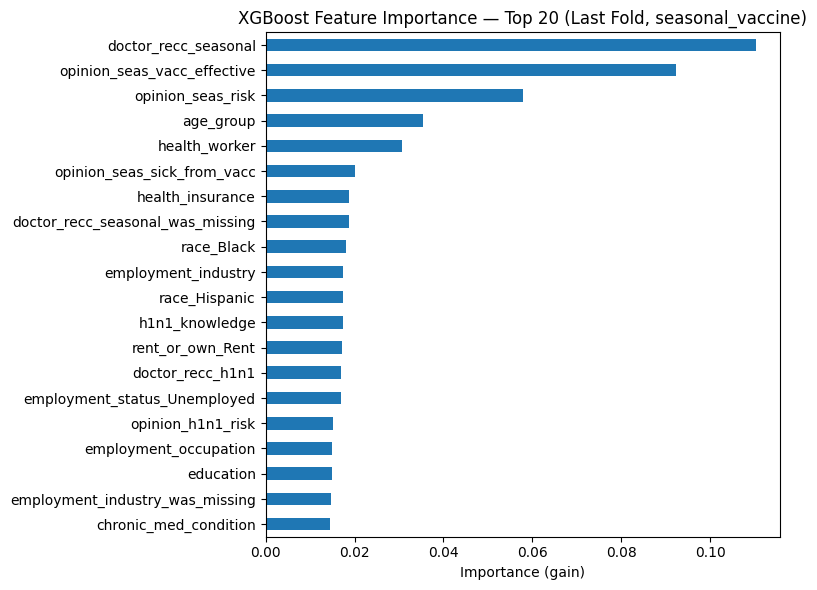

In [9]:
import matplotlib
try:
    import matplotlib.pyplot as plt
    fi = pd.Series(
        model.feature_importances_,
        index=X_tr.columns
    ).sort_values(ascending=False).head(20)

    fig, ax = plt.subplots(figsize=(8, 6))
    fi.plot(kind='barh', ax=ax)
    ax.set_title('XGBoost Feature Importance — Top 20 (Last Fold, seasonal_vaccine)')
    ax.set_xlabel('Importance (gain)')
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f'Skipping plot: {e}')
    fi = pd.Series(
        model.feature_importances_,
        index=X_tr.columns
    ).sort_values(ascending=False).head(20)
    print(fi.to_string())